In [1]:
#pip install folium

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium

In [3]:
dataset_path = "Map-Crime_Incidents-Previous_Three_Months.csv"
SF = pd.read_csv(dataset_path)

In [4]:
SF.head()

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Location
0,NaN,LARCENY/THEFT,GRAND THEFT FROM UNLOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,20:30,CENTRAL,NONE,HYDE ST / CALIFORNIA ST,-122.417393,37.790974,"(37.7909741243888, -122.417392830334)"
1,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,14:30,CENTRAL,NONE,COLUMBUS AV / JACKSON ST,-122.404418,37.796302,"(37.7963018736036, -122.404417620748)"
2,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,11:30,CENTRAL,NONE,SUTTER ST / STOCKTON ST,-122.406959,37.789435,"(37.7894347630337, -122.406958660602)"
3,NaN,DRUG/NARCOTIC,POSSESSION OF METH-AMPHETAMINE,Sunday,08/31/2014 07:00:00 AM +0000,17:49,MISSION,"ARREST, BOOKED",16TH ST / MISSION ST,-122.419672,37.765050,"(37.7650501214965, -122.419671780296)"
4,NaN,DRUG/NARCOTIC,POSSESSION OF COCAINE,Sunday,08/31/2014 07:00:00 AM +0000,18:05,NORTHERN,"ARREST, BOOKED",LARKIN ST / OFARRELL ST,-122.417904,37.785167,"(37.7851670875814, -122.417903977564)"


In [5]:
pd.set_option('display.max_rows', 8)
SF

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Location
0,NaN,LARCENY/THEFT,GRAND THEFT FROM UNLOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,20:30,CENTRAL,NONE,HYDE ST / CALIFORNIA ST,-122.417393,37.790974,"(37.7909741243888, -122.417392830334)"
1,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,14:30,CENTRAL,NONE,COLUMBUS AV / JACKSON ST,-122.404418,37.796302,"(37.7963018736036, -122.404417620748)"
2,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,11:30,CENTRAL,NONE,SUTTER ST / STOCKTON ST,-122.406959,37.789435,"(37.7894347630337, -122.406958660602)"
3,NaN,DRUG/NARCOTIC,POSSESSION OF METH-AMPHETAMINE,Sunday,08/31/2014 07:00:00 AM +0000,17:49,MISSION,"ARREST, BOOKED",16TH ST / MISSION ST,-122.419672,37.765050,"(37.7650501214965, -122.419671780296)"
...,...,...,...,...,...,...,...,...,...,...,...,...
30756,NaN,OTHER OFFENSES,"DRIVERS LICENSE, SUSPENDED OR REVOKED",Sunday,06/01/2014 07:00:00 AM +0000,16:00,NORTHERN,"ARREST, CITED",POLK ST / MCALLISTER ST,-122.418601,37.780261,"(37.7802607511488, -122.418600974625)"
30757,NaN,ASSAULT,BATTERY,Sunday,06/01/2014 07:00:00 AM +0000,15:00,TENDERLOIN,"ARREST, CITED",0.0 Block of JONES ST,-122.412122,37.781379,"(37.7813786419025, -122.412121608136)"
30758,NaN,ASSAULT,ASSAULT WITH CAUSTIC CHEMICALS,Sunday,06/01/2014 07:00:00 AM +0000,15:20,CENTRAL,NONE,200.0 Block of GEARY ST,-122.407434,37.787494,"(37.7874944447786, -122.407434204569)"
30759,NaN,OTHER OFFENSES,"DRIVERS LICENSE, SUSPENDED OR REVOKED",Sunday,06/01/2014 07:00:00 AM +0000,13:15,INGLESIDE,"ARREST, CITED",MISSION ST / BOSWORTH ST,-122.426391,37.733675,"(37.7336749150401, -122.426391018521)"


In [6]:
SF.columns

Index(['IncidntNum', 'Category', 'Descript', 'DayOfWeek', 'Date', 'Time',
       'PdDistrict', 'Resolution', 'Address', 'X', 'Y', 'Location'],
      dtype='str')

In [7]:
print(len(SF))
SF.head(2)

30760


,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Location
0,NaN,LARCENY/THEFT,GRAND THEFT FROM UNLOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,20:30,CENTRAL,NONE,HYDE ST / CALIFORNIA ST,-122.417393,37.790974,"(37.7909741243888, -122.417392830334)"
1,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,14:30,CENTRAL,NONE,COLUMBUS AV / JACKSON ST,-122.404418,37.796302,"(37.7963018736036, -122.404417620748)"


In [8]:
SF['Date']

0        08/31/2014 07:00:00 AM +0000
1        08/31/2014 07:00:00 AM +0000
2        08/31/2014 07:00:00 AM +0000
3        08/31/2014 07:00:00 AM +0000
                     ...             
30756    06/01/2014 07:00:00 AM +0000
30757    06/01/2014 07:00:00 AM +0000
30758    06/01/2014 07:00:00 AM +0000
30759    06/01/2014 07:00:00 AM +0000
Name: Date, Length: 30760, dtype: str

In [9]:
SF['Month'] = SF['Date'].apply(lambda row: int(row[0:2]))
SF['Day'] = SF['Date'].apply(lambda row: int(row[3:5]))
SF.head(5)

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Location,Month,Day
0,NaN,LARCENY/THEFT,GRAND THEFT FROM UNLOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,20:30,CENTRAL,NONE,HYDE ST / CALIFORNIA ST,-122.417393,37.790974,"(37.7909741243888, -122.417392830334)",8,31
1,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,14:30,CENTRAL,NONE,COLUMBUS AV / JACKSON ST,-122.404418,37.796302,"(37.7963018736036, -122.404417620748)",8,31
2,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,11:30,CENTRAL,NONE,SUTTER ST / STOCKTON ST,-122.406959,37.789435,"(37.7894347630337, -122.406958660602)",8,31
3,NaN,DRUG/NARCOTIC,POSSESSION OF METH-AMPHETAMINE,Sunday,08/31/2014 07:00:00 AM +0000,17:49,MISSION,"ARREST, BOOKED",16TH ST / MISSION ST,-122.419672,37.765050,"(37.7650501214965, -122.419671780296)",8,31
4,NaN,DRUG/NARCOTIC,POSSESSION OF COCAINE,Sunday,08/31/2014 07:00:00 AM +0000,18:05,NORTHERN,"ARREST, BOOKED",LARKIN ST / OFARRELL ST,-122.417904,37.785167,"(37.7851670875814, -122.417903977564)",8,31


In [10]:
print(SF['Month'][0:2])
print(SF['Day'][0:2])

0    8
1    8
Name: Month, dtype: int64
0    31
1    31
Name: Day, dtype: int64


In [11]:
#del SF['IncidntNum']
SF.head(1)
SF.to_csv('test.csv')

In [12]:
SF.drop('Location', axis=1, inplace=True)

In [13]:
SF

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Month,Day
0,NaN,LARCENY/THEFT,GRAND THEFT FROM UNLOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,20:30,CENTRAL,NONE,HYDE ST / CALIFORNIA ST,-122.417393,37.790974,8,31
1,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,14:30,CENTRAL,NONE,COLUMBUS AV / JACKSON ST,-122.404418,37.796302,8,31
2,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,11:30,CENTRAL,NONE,SUTTER ST / STOCKTON ST,-122.406959,37.789435,8,31
3,NaN,DRUG/NARCOTIC,POSSESSION OF METH-AMPHETAMINE,Sunday,08/31/2014 07:00:00 AM +0000,17:49,MISSION,"ARREST, BOOKED",16TH ST / MISSION ST,-122.419672,37.765050,8,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30756,NaN,OTHER OFFENSES,"DRIVERS LICENSE, SUSPENDED OR REVOKED",Sunday,06/01/2014 07:00:00 AM +0000,16:00,NORTHERN,"ARREST, CITED",POLK ST / MCALLISTER ST,-122.418601,37.780261,6,1
30757,NaN,ASSAULT,BATTERY,Sunday,06/01/2014 07:00:00 AM +0000,15:00,TENDERLOIN,"ARREST, CITED",0.0 Block of JONES ST,-122.412122,37.781379,6,1
30758,NaN,ASSAULT,ASSAULT WITH CAUSTIC CHEMICALS,Sunday,06/01/2014 07:00:00 AM +0000,15:20,CENTRAL,NONE,200.0 Block of GEARY ST,-122.407434,37.787494,6,1
30759,NaN,OTHER OFFENSES,"DRIVERS LICENSE, SUSPENDED OR REVOKED",Sunday,06/01/2014 07:00:00 AM +0000,13:15,INGLESIDE,"ARREST, CITED",MISSION ST / BOSWORTH ST,-122.426391,37.733675,6,1


In [14]:
CountCategory = SF['Category'].value_counts()
print(CountCategory)

Category
LARCENY/THEFT              8205
OTHER OFFENSES             4004
NON-CRIMINAL               3653
ASSAULT                    2518
                           ... 
BAD CHECKS                    3
GAMBLING                      1
PORNOGRAPHY/OBSCENE MAT       1
BRIBERY                       1
Name: count, Length: 36, dtype: int64


In [15]:
SF['Category'].value_counts(ascending=True)

Category
GAMBLING                      1
PORNOGRAPHY/OBSCENE MAT       1
BRIBERY                       1
BAD CHECKS                    3
                           ... 
ASSAULT                    2518
NON-CRIMINAL               3653
OTHER OFFENSES             4004
LARCENY/THEFT              8205
Name: count, Length: 36, dtype: int64

In [16]:
SF['PdDistrict'].value_counts(ascending=False)


PdDistrict
SOUTHERN      6185
MISSION       4011
CENTRAL       3867
NORTHERN      3205
              ... 
TENDERLOIN    2449
TARAVAL       2038
PARK          1800
RICHMOND      1622
Name: count, Length: 10, dtype: int64

In [17]:
AugustCrimes = SF[SF['Month'] == 8]
AugustCrimes

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Month,Day
0,NaN,LARCENY/THEFT,GRAND THEFT FROM UNLOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,20:30,CENTRAL,NONE,HYDE ST / CALIFORNIA ST,-122.417393,37.790974,8,31
1,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,14:30,CENTRAL,NONE,COLUMBUS AV / JACKSON ST,-122.404418,37.796302,8,31
2,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,08/31/2014 07:00:00 AM +0000,11:30,CENTRAL,NONE,SUTTER ST / STOCKTON ST,-122.406959,37.789435,8,31
3,NaN,DRUG/NARCOTIC,POSSESSION OF METH-AMPHETAMINE,Sunday,08/31/2014 07:00:00 AM +0000,17:49,MISSION,"ARREST, BOOKED",16TH ST / MISSION ST,-122.419672,37.765050,8,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9716,NaN,OTHER OFFENSES,MISCELLANEOUS INVESTIGATION,Friday,08/01/2014 07:00:00 AM +0000,22:47,RICHMOND,NONE,1500.0 Block of BRODERICK ST,-122.441458,37.784427,8,1
9717,NaN,ASSAULT,THREATS AGAINST LIFE,Friday,08/01/2014 07:00:00 AM +0000,23:55,BAYVIEW,NONE,400.0 Block of TUNNEL AV,-122.401364,37.709748,8,1
9718,NaN,DRIVING UNDER THE INFLUENCE,DRIVING WHILE UNDER THE INFLUENCE OF ALCOHOL,Friday,08/01/2014 07:00:00 AM +0000,23:38,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,8,1
9719,NaN,"SEX OFFENSES, FORCIBLE",ASSAULT TO RAPE WITH BODILY FORCE,Friday,08/01/2014 07:00:00 AM +0000,00:01,MISSION,NONE,1000.0 Block of POTRERO AV,-122.406657,37.756826,8,1


In [18]:
AugustCrimesBurglary = AugustCrimes[AugustCrimes['Category'] == "BURGLARY"]
AugustCrimesBurglary

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Month,Day
185,NaN,BURGLARY,"BURGLARY OF STORE, UNLAWFUL ENTRY",Friday,08/29/2014 07:00:00 AM +0000,16:01,SOUTHERN,"ARREST, BOOKED",800.0 Block of MARKET ST,-122.407414,37.784552,8,29
212,NaN,BURGLARY,"BURGLARY, HOT PROWL, ATTEMPTED FORCIBLE ENTRY",Friday,08/29/2014 07:00:00 AM +0000,10:30,INGLESIDE,NONE,600.0 Block of JARBOE AV,-122.412576,37.738381,8,29
240,NaN,BURGLARY,"BURGLARY, HOT PROWL, UNLAWFUL ENTRY",Thursday,08/28/2014 07:00:00 AM +0000,08:00,CENTRAL,NONE,0.0 Block of SPOFFORD LN,-122.407246,37.794544,8,28
251,NaN,BURGLARY,"BURGLARY,STORE UNDER CONSTRUCTION, UNLAWFUL ENTRY",Thursday,08/28/2014 07:00:00 AM +0000,06:14,BAYVIEW,NONE,2900.0 Block of 3RD ST,-122.387650,37.752138,8,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9579,NaN,BURGLARY,"BURGLARY, UNLAWFUL ENTRY",Friday,08/01/2014 07:00:00 AM +0000,19:35,NORTHERN,"ARREST, BOOKED",1700.0 Block of OFARRELL ST,-122.433604,37.783143,8,1
9615,NaN,BURGLARY,"BURGLARY OF APARTMENT HOUSE, UNLAWFUL ENTRY",Friday,08/01/2014 07:00:00 AM +0000,04:00,NORTHERN,NONE,1100.0 Block of SUTTER ST,-122.419458,37.787952,8,1
9616,NaN,BURGLARY,"BURGLARY,STORE UNDER CONSTRUCTION, UNLAWFUL ENTRY",Friday,08/01/2014 07:00:00 AM +0000,15:30,SOUTHERN,"ARREST, BOOKED",100.0 Block of 8TH ST,-122.412311,37.776827,8,1
9627,NaN,BURGLARY,"BURGLARY OF APARTMENT HOUSE, UNLAWFUL ENTRY",Friday,08/01/2014 07:00:00 AM +0000,02:50,SOUTHERN,NONE,0.0 Block of BERNICE ST,-122.413859,37.770213,8,1


In [19]:
Crime0704 = SF.query('Month == 7 and Day == 4')
Crime0704

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Month,Day
19087,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Friday,07/04/2014 07:00:00 AM +0000,22:30,SOUTHERN,NONE,8TH ST / MISSION ST,-122.413161,37.777457,7,4
19088,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Friday,07/04/2014 07:00:00 AM +0000,18:15,SOUTHERN,NONE,CLEMENTINA ST / 9TH ST,-122.412174,37.774201,7,4
19089,NaN,BURGLARY,"BURGLARY,RESIDENCE UNDER CONSTRT, FORCIBLE ENTRY",Friday,07/04/2014 07:00:00 AM +0000,00:50,TARAVAL,NONE,0.0 Block of MENDOSA AV,-122.466414,37.748011,7,4
19090,NaN,NON-CRIMINAL,LOST PROPERTY,Friday,07/04/2014 07:00:00 AM +0000,19:00,PARK,NONE,CASTRO ST / 16TH ST,-122.435318,37.764102,7,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19424,NaN,OTHER OFFENSES,LOST/STOLEN LICENSE PLATE,Friday,07/04/2014 07:00:00 AM +0000,11:00,INGLESIDE,NONE,0.0 Block of FRATESSA CT,-122.399762,37.716129,7,4
19425,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Friday,07/04/2014 07:00:00 AM +0000,20:30,SOUTHERN,NONE,THE EMBARCADEROSOUTH ST / HARRISON ST,-122.388486,37.789573,7,4
19426,NaN,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Friday,07/04/2014 07:00:00 AM +0000,08:00,SOUTHERN,NONE,11TH ST / HARRISON ST,-122.412483,37.770631,7,4
19427,NaN,LARCENY/THEFT,PETTY THEFT OF PROPERTY,Friday,07/04/2014 07:00:00 AM +0000,15:30,RICHMOND,NONE,3900.0 Block of GEARY BL,-122.461295,37.781181,7,4


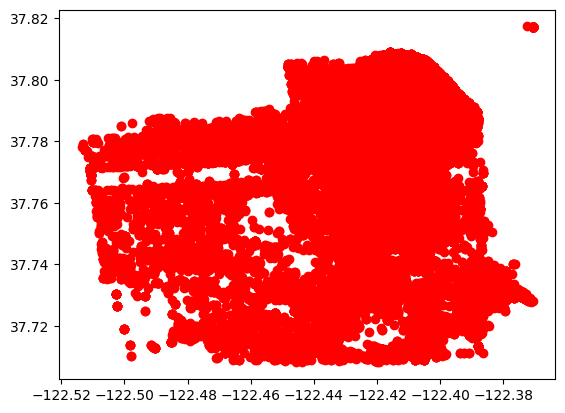

In [20]:
plt.plot(SF['X'], SF['Y'], 'ro')
plt.show()

In [21]:
pd_districts = np.unique(SF['PdDistrict'])
print(pd_districts)
pd_districts_levels = dict(zip(pd_districts, range(len(pd_districts))))
print(pd_districts_levels)

['BAYVIEW' 'CENTRAL' 'INGLESIDE' 'MISSION' 'NORTHERN' 'PARK' 'RICHMOND'
 'SOUTHERN' 'TARAVAL' 'TENDERLOIN']
{'BAYVIEW': 0, 'CENTRAL': 1, 'INGLESIDE': 2, 'MISSION': 3, 'NORTHERN': 4, 'PARK': 5, 'RICHMOND': 6, 'SOUTHERN': 7, 'TARAVAL': 8, 'TENDERLOIN': 9}


In [22]:
SF['PdDistrictCode'] = SF['PdDistrict'].apply(lambda row: pd_districts_levels[row])

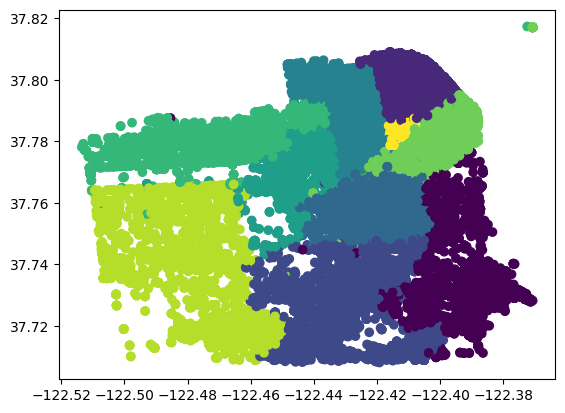

In [23]:
plt.scatter(SF['X'], SF['Y'], c=SF['PdDistrictCode'])
plt.show()

In [24]:
from matplotlib import colors

districts = np.unique(SF['PdDistrict'])
print(districts)
print(colors.cnames.values())
print(colors.cnames)
print(list(colors.cnames.values())[0:len(districts)])

['BAYVIEW' 'CENTRAL' 'INGLESIDE' 'MISSION' 'NORTHERN' 'PARK' 'RICHMOND'
 'SOUTHERN' 'TARAVAL' 'TENDERLOIN']
dict_values(['#F0F8FF', '#FAEBD7', '#00FFFF', '#7FFFD4', '#F0FFFF', '#F5F5DC', '#FFE4C4', '#000000', '#FFEBCD', '#0000FF', '#8A2BE2', '#A52A2A', '#DEB887', '#5F9EA0', '#7FFF00', '#D2691E', '#FF7F50', '#6495ED', '#FFF8DC', '#DC143C', '#00FFFF', '#00008B', '#008B8B', '#B8860B', '#A9A9A9', '#006400', '#A9A9A9', '#BDB76B', '#8B008B', '#556B2F', '#FF8C00', '#9932CC', '#8B0000', '#E9967A', '#8FBC8F', '#483D8B', '#2F4F4F', '#2F4F4F', '#00CED1', '#9400D3', '#FF1493', '#00BFFF', '#696969', '#696969', '#1E90FF', '#B22222', '#FFFAF0', '#228B22', '#FF00FF', '#DCDCDC', '#F8F8FF', '#FFD700', '#DAA520', '#808080', '#008000', '#ADFF2F', '#808080', '#F0FFF0', '#FF69B4', '#CD5C5C', '#4B0082', '#FFFFF0', '#F0E68C', '#E6E6FA', '#FFF0F5', '#7CFC00', '#FFFACD', '#ADD8E6', '#F08080', '#E0FFFF', '#FAFAD2', '#D3D3D3', '#90EE90', '#D3D3D3', '#FFB6C1', '#FFA07A', '#20B2AA', '#87CEFA', '#778899', '#778899',

In [25]:
color_dict = dict(zip(districts, list(colors.cnames.values())[0:-1:len(districts)]))
print(color_dict)

{'BAYVIEW': '#F0F8FF', 'CENTRAL': '#8A2BE2', 'INGLESIDE': '#00FFFF', 'MISSION': '#FF8C00', 'NORTHERN': '#FF1493', 'PARK': '#F8F8FF', 'RICHMOND': '#4B0082', 'SOUTHERN': '#FAFAD2', 'TARAVAL': '#B0C4DE', 'TENDERLOIN': '#9370DB'}


In [26]:
map_osm = folium.Map(tiles="OpenStreetMap", zoom_start=10,
                     max_zoom=23, control_scale=True,
                     location=[
                         SF['Y'].mean(),
                         SF['X'].mean()
                     ])

plotEvery = 5
obs = list(zip(SF['Y'], SF['X'], SF['PdDistrict']))

for el in obs[0:-1:plotEvery]:
    folium.CircleMarker(
        el[0:2], color=color_dict[el[2]],
        fill_color=el[2], radius=10
    ).add_to(map_osm)

map_osm